# Module 2: Epidemic Modeling 

## Team Members:
Amelia Luongo and Isabella Imburgia

## Project Title:
Utilizing SEIR Model to Predict Disease Behavior 

## Project Goal:
This project seeks to predict the spread of a mystery virus throughout the University of Virginia and Virginia Tech campus populations and to determine which intervention strategy is the most effective.

## AI Usage Statement:
ChatGPT was used to debug code and correct syntax errors. 

## 1. Data and disease background
The initial susceptible population was 17,900 students at the University of Virginia. There was 1 initial active case reported on day 1 March 1, 2026 and eventually reached a peak of 3006 active daily reported cases on day 87. Transmission of this mystery disease is via respiratory droplets and it was found to be classified as a positive sense RNA virus (~10kb) with a size of 50-80 nm. The incubation period is 12-18 days, the infectious period is 2 days before symptom onset, and the symptomatic period is 5-9 days. The symptoms include mild respiratory symptoms, rash, low-grade fever, sore throat, fatigue, joint point, and gastrointestinal symptoms in 8% of cases. There is an economic burden associated with the spread of respiratory viruses including the cost of medical care (vaccines, medicines, masks), missed days of work which could lead to a loss of revenue for an individual or a company, and the systemic costs for businesses and hospitals if there are less patrons or more patients. 

Biologically, this virus spreads through respiratory droplets that then enter a susceptible person. At a cellular level, the virus enters the host cell and "hacks" its machinery to replicate the viral RNA and producing mRNA to synthesize the viral proteins. The new virions are then released from the host cell and spread to infect other cells in the body to continue the viral cycle. 

Within the UVA population, the infection peaks at around 3000 out of 17000 students. This indicated a peak prevalence around 17%. 





## 2. Data Analysis


### 2a. Methods

To analyze the data, we initially plotted the days versus number of active infections with the data provided from data release 1. This provided a visual representation of the exponential growth which we then fit a model to using numpy, pandas, scipy, and matplot. We also determined an R0 from the exponential growth fit using the equation R0 = r*D. After we determined our R0 value, we researched other diseases with similar R0 values to give preliminary possibilities as to what the virus could be. The next step was to use Euler's method to solve the SEIR model now incorporating two data releases that spanned 70 days. Using a grid search, we optimized the disease parameters beta, gamma, and sigma to better fit the SEIR model. The next task was to plot the SEIR model on top of the provided data for the first 70 days and use the model to predict the peak number of infections and on what day this would occur. To see how accurate our SEIR model prediction was, we plotted it against the full data set consisting of 120 days and calculated the percent error between the actual data and our model predictions. Lastly, we altered the biological parameters to model different intervention strategies in Virginia Tech's student population to find which was the most effective in reducing the number of infections. 


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)

The following plots estimate an exponential growth path of the infections based on the first 45 days of data.

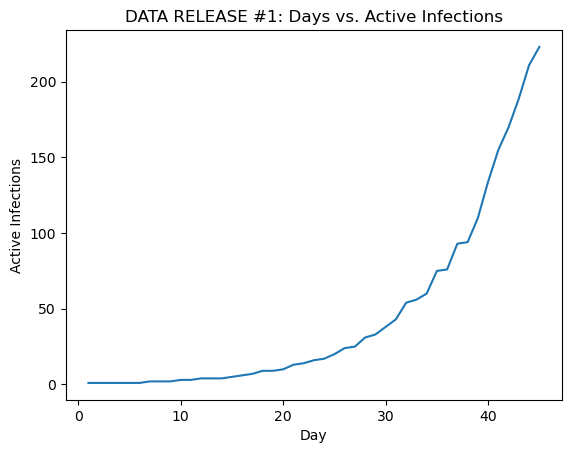

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# creating a graph that shows the number of active infections each day
df = pd.read_csv("/Users/amelialuongo/Desktop/comp bme/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv")

# Plot day vs active infections
plt.figure()
plt.plot(df["day"], df["active reported daily cases"])
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("DATA RELEASE #1: Days vs. Active Infections")
plt.show()


The initial infection spreads very slowly. There is only one active infection for the first 6 days of tracking, and only 2 infections for the following 3 days. The spread of the infection picks up a lot around day 30 and begins to look more like exponential growth. The growth rate can be modeled using a line of best fit from a regression model. Knowing more information such as the transmission rate, incubation rate, and recovery period would be helpful for determining the shape of the outbreak curve. This would help calculate the R0 value and figure out how many people are being infected from each sick person. It will also show how long it take for someone to move from an active infection to a recovered state, bringing the active cases back down.

Estimated R0 value: 1.8353473887136755


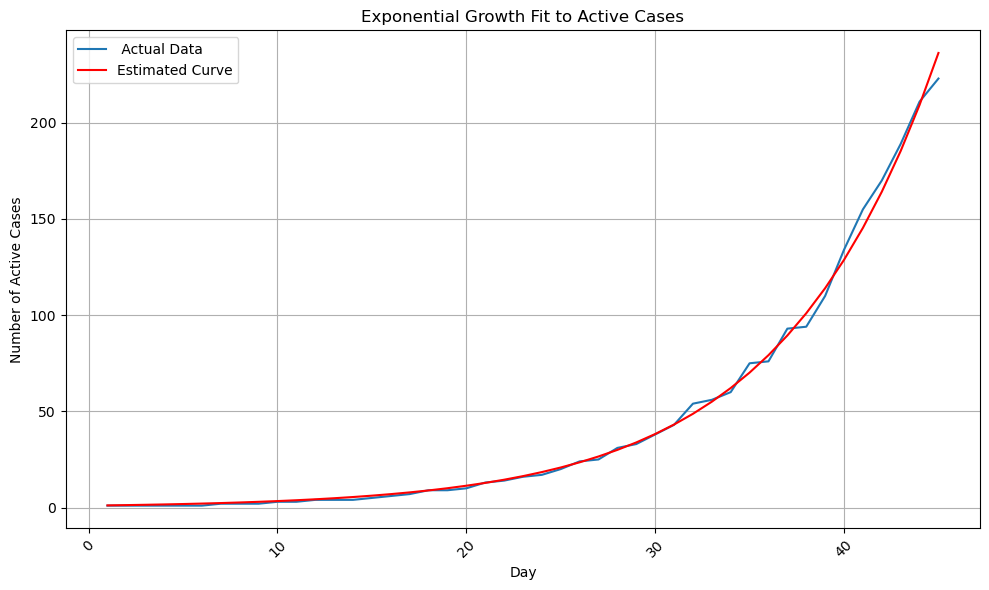

In [6]:
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

# Define a class to represent the virus data
#calculate the R0 value from early data csv file (first 45 days)
def eponential_growth(t,r):
    return np.exp(r*t)

x_data = data['day'].values.astype(float)
y_data = data['active reported daily cases'].values.astype(float)
popt, pcov = curve_fit(eponential_growth, x_data, y_data)
r_fit = popt[0]

D = 5 # estimated infection period from data 

r0 = np.exp(r_fit * D)

print("Estimated R0 value:", r0)
# add the fitted curve to the plot
y_fitted = eponential_growth(x_data, r_fit)
# plot fitted curve and actual data
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, label=' Actual Data')
plt.plot(x_data, y_fitted, color = "red", label = "Estimated Curve")
plt.title('Exponential Growth Fit to Active Cases')
plt.xlabel('Day')
plt.ylabel('Number of Active Cases')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

The estimated R0 value is 1.835. Other diseases that have a similar R0 value are Influenza (H1N1 2009) with an R0 value of 1.5 and Ebola with an R0 value of 2.0. The 2009 Influenza A strain was coined "swine flu" and spread rapidly throughout the globe through respiratory droplets. It had a relatively low fatality rate of 0.02% but was impactful enough that the World Health Organization declared a pandemic. While Ebola has a similar R0 value, it has a much higher ratality rate around 60%. It is transmitted through direct contact with infected bodily fluid and symptoms include fever, fatigue, vomiting/diarrhea, rash, and bleeding. Our R0 estimate at this stage is based on limited data, so it may not be accurate however it is a good estimate based on the data provided. 


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.

Euler's method is modeled below using differential equations to apply the SEIR model to a given data set of infections. It is optimizing the parameters to predict the infection curve using data through day 70. 

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#%%
# Load the data
data = pd.read_csv(
    '/Users/amelialuongo/Desktop/comp bme/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv',
    parse_dates=['date']
)

# Observed infected data
data_I = data["active reported daily cases"].to_numpy()
timepoints = data["day"].to_numpy()

# Initial conditions
I0 = data_I[0]
E0 = 0
R0 = 1.835
S0 = N - I0

#%%
# Euler SEIR function
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N, dt=1):

    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]

    for t in range(len(timepoints)-1):

        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S_new = S[-1] + dS * dt
        E_new = E[-1] + dE * dt
        I_new = I[-1] + dI * dt
        R_new = R[-1] + dR * dt

        S.append(S_new)
        E.append(E_new)
        I.append(I_new)
        R.append(R_new)

    return np.array(S), np.array(E), np.array(I), np.array(R)


# Observed infected data
data_I = data["active reported daily cases"].to_numpy()
timepoints = data["day"].to_numpy()




### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
The optimal beta, gamma, and sigma are calculated using a gridsearch.

In [9]:
#%%
# Observed infected data
data_I = data["active reported daily cases"].to_numpy()
timepoints = data["day"].to_numpy()

# Population size (larger so infections aren't capped)
N = 17000

# Initial conditions
I0 = data_I[0]
E0 = 0
R0 = 1.835
S0 = N - I0

#%%
# Parameter ranges
beta_range = np.linspace(0.01, 1, 30)
sigma_range = np.linspace(0.01, 1, 30)
gamma_range = np.linspace(0.01, 1, 30)

best_beta = None
best_sigma = None
best_gamma = None
best_SSE = np.inf

# Grid search
for b in beta_range:
    for s in sigma_range:
        for g in gamma_range:

            S, E, I, R = euler_seir(b, s, g, S0, E0, I0, R0, timepoints, N)

            I_model = I[:len(data_I)]

            sse = np.sum((data_I - I_model)**2)

            if sse < best_SSE:
                best_SSE = sse
                best_beta = b
                best_sigma = s
                best_gamma = g

#%%
print("Best beta:", best_beta)
print("Best sigma:", best_sigma)
print("Best gamma:", best_gamma)
print("Best SSE:", best_SSE)


Best beta: 0.4537931034482759
Best sigma: 0.3513793103448276
Best gamma: 0.1806896551724138
Best SSE: 103649.51289822998


### 2e. Plot the model-predicted infections over time compared to the data.
The following code compares the model to the actual data points on a graph. 

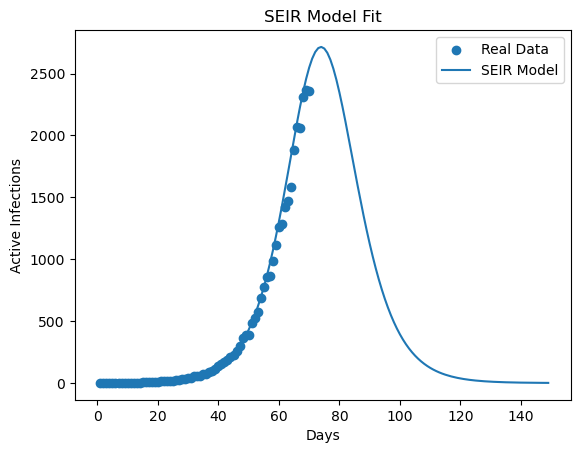

In [10]:
#%%
# Predict future outbreak
future_days = 150
timepoints_future = np.arange(0, future_days)

S, E, I, R = euler_seir(
    best_beta,
    best_sigma,
    best_gamma,
    S0,
    E0,
    I0,
    R0,
    timepoints_future,
    N
)

#%%
# Peak analysis
peak_height = np.max(I)
peak_day = np.argmax(I)

#%%
# Plot results
plt.figure()

plt.scatter(
    data["day"],
    data["active reported daily cases"],
    label="Real Data"
)

plt.plot(
    timepoints_future,
    I,
    label="SEIR Model"
)

plt.xlabel("Days")
plt.ylabel("Active Infections")
plt.title("SEIR Model Fit")
plt.legend()

plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.




In [ ]:
#%%
# Peak analysis
peak_height = np.max(I)
peak_day = np.argmax(I)

print("Peak infections:", peak_height)
print("Peak occurs on day:", peak_day)


Peak infections: 2715.0463016164344
Peak occurs on day: 74



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
The final graph shows the full data set plotted against the SEIR model. The parameters are optimized to this data set. 


Peak infections: 3643.5605253111385
Peak occurs on day: 80


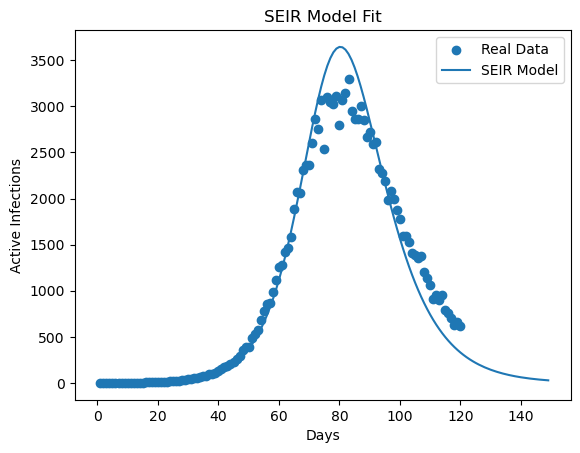

In [ ]:
# Load the data
data = pd.read_csv(
    '/Users/amelialuongo/Desktop/comp bme/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv',
    parse_dates=['date']
)

#%%
# Euler SEIR function
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N, dt=1):

    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]

    for t in range(len(timepoints)-1):

        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S_new = S[-1] + dS * dt
        E_new = E[-1] + dE * dt
        I_new = I[-1] + dI * dt
        R_new = R[-1] + dR * dt

        S.append(S_new)
        E.append(E_new)
        I.append(I_new)
        R.append(R_new)

    return np.array(S), np.array(E), np.array(I), np.array(R)

#%%
# Observed infected data
data_I = data["active reported daily cases"].to_numpy()
timepoints = data["day"].to_numpy()

# Population size (larger so infections aren't capped)
N = 17000

# Initial conditions
I0 = data_I[0]
E0 = 0
R0 = 1.835
S0 = N - I0

#%%
# Parameter ranges
beta_range = np.linspace(0.01, 1, 30)
sigma_range = np.linspace(0.01, 1, 30)
gamma_range = np.linspace(0.01, 1, 30)

best_beta = None
best_sigma = None
best_gamma = None
best_SSE = np.inf

# Grid search
for b in beta_range:
    for s in sigma_range:
        for g in gamma_range:

            S, E, I, R = euler_seir(b, s, g, S0, E0, I0, R0, timepoints, N)

            I_model = I[:len(data_I)]

            sse = np.sum((data_I - I_model)**2)

            if sse < best_SSE:
                best_SSE = sse
                best_beta = b
                best_sigma = s
                best_gamma = g

#%%
# Predict future outbreak
future_days = 150
timepoints_future = np.arange(0, future_days)

S, E, I, R = euler_seir(
    best_beta,
    best_sigma,
    best_gamma,
    S0,
    E0,
    I0,
    R0,
    timepoints_future,
    N
)

#%%
# Peak analysis
peak_height = np.max(I)
peak_day = np.argmax(I)

print("Peak infections:", peak_height)
print("Peak occurs on day:", peak_day)

#%%
# Plot results
plt.figure()

plt.scatter(
    data["day"],
    data["active reported daily cases"],
    label="Real Data"
)

plt.plot(
    timepoints_future,
    I,
    label="SEIR Model"
)

plt.xlabel("Days")
plt.ylabel("Active Infections")
plt.title("SEIR Model Fit")
plt.legend()

plt.show()

### Error calculations:

Actual peak infections: 3109 cases

Predicted peak by model: 3643.56 cases

Percent error: 17.19%

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)





1. Immediate masking from day 70

- Implementing a mask mandate that reduces the transmission rate (beta) by 40%

2. Vaccine campaign

- Creating a vaccine event where 2000 vaccines are administered to the population with a 90% efficacy

3. Vaccine rollout

- 3 rounds of vaccines are administered on days 70, 80, and 90
- Each round vaccinates 1000 students with 90% efficacy

4. Testing and quarantine

- Being able to test and self quarantine reduces the infectious period by 2 days

5. Close school for 2 weeks

- For the 2 weeks of school closure, transmission is decreased by reducing 80% of normal contact

These strategies are modeled by adjusting the parameters and SEIR buckets. The graph below compares the number of infections that would occur if these interventions are implemented in comparison to the baseline model. 

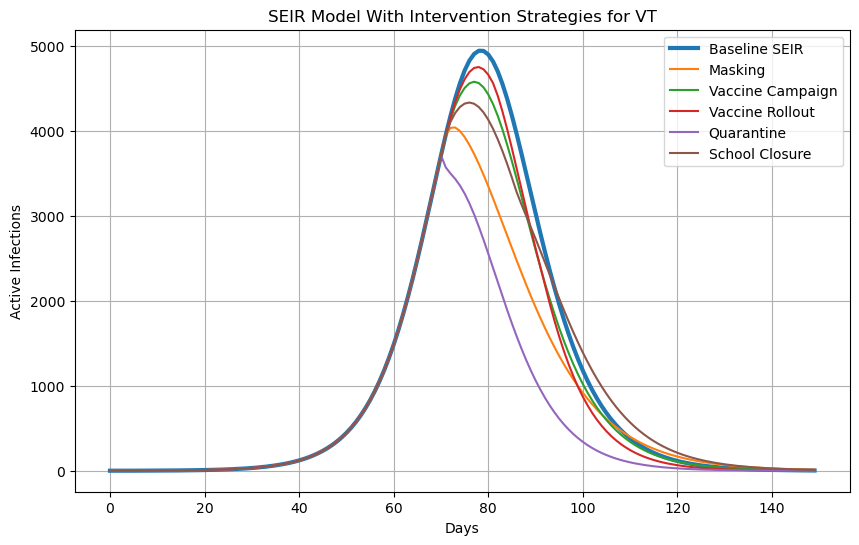

In [11]:
#%% INTERVENTION STRATEGIES

import numpy as np
import matplotlib.pyplot as plt

# Updated population
N = 31000
S0 = N - I0

future_days = 150
timepoints_future = np.arange(0, future_days)

# -----------------------------
# Baseline SEIR
# -----------------------------

S_base = [S0]
E_base = [E0]
I_base = [I0]
R_base = [R0]

for t in range(future_days-1):

    dS = -best_beta * S_base[-1] * I_base[-1] / N
    dE = best_beta * S_base[-1] * I_base[-1] / N - best_sigma * E_base[-1]
    dI = best_sigma * E_base[-1] - best_gamma * I_base[-1]
    dR = best_gamma * I_base[-1]

    S_base.append(S_base[-1] + dS)
    E_base.append(E_base[-1] + dE)
    I_base.append(I_base[-1] + dI)
    R_base.append(R_base[-1] + dR)

I_base = np.array(I_base)


# -----------------------------
# 1 Masking (β reduced 40% after day 70)
# -----------------------------

S_mask = [S0]
E_mask = [E0]
I_mask = [I0]
R_mask = [R0]

for t in range(future_days-1):

    beta_current = best_beta

    if t >= 70:
        beta_current = best_beta * 0.6

    dS = -beta_current * S_mask[-1] * I_mask[-1] / N
    dE = beta_current * S_mask[-1] * I_mask[-1] / N - best_sigma * E_mask[-1]
    dI = best_sigma * E_mask[-1] - best_gamma * I_mask[-1]
    dR = best_gamma * I_mask[-1]

    S_mask.append(S_mask[-1] + dS)
    E_mask.append(E_mask[-1] + dE)
    I_mask.append(I_mask[-1] + dI)
    R_mask.append(R_mask[-1] + dR)

I_mask = np.array(I_mask)


# -----------------------------
# 2 Vaccine Campaign
# 1800 vaccinated day 70
# -----------------------------

S_camp = [S0]
E_camp = [E0]
I_camp = [I0]
R_camp = [R0]

for t in range(future_days-1):

    if t == 70:
        S_camp[-1] -= 1800
        R_camp[-1] += 1800

    dS = -best_beta * S_camp[-1] * I_camp[-1] / N
    dE = best_beta * S_camp[-1] * I_camp[-1] / N - best_sigma * E_camp[-1]
    dI = best_sigma * E_camp[-1] - best_gamma * I_camp[-1]
    dR = best_gamma * I_camp[-1]

    S_camp.append(S_camp[-1] + dS)
    E_camp.append(E_camp[-1] + dE)
    I_camp.append(I_camp[-1] + dI)
    R_camp.append(R_camp[-1] + dR)

I_camp = np.array(I_camp)


# -----------------------------
# 3 Vaccine Rollout
# 900 vaccinated on days 70,80,90
# -----------------------------

S_roll = [S0]
E_roll = [E0]
I_roll = [I0]
R_roll = [R0]

for t in range(future_days-1):

    if t in [70,80,90]:
        S_roll[-1] -= 900
        R_roll[-1] += 900

    dS = -best_beta * S_roll[-1] * I_roll[-1] / N
    dE = best_beta * S_roll[-1] * I_roll[-1] / N - best_sigma * E_roll[-1]
    dI = best_sigma * E_roll[-1] - best_gamma * I_roll[-1]
    dR = best_gamma * I_roll[-1]

    S_roll.append(S_roll[-1] + dS)
    E_roll.append(E_roll[-1] + dE)
    I_roll.append(I_roll[-1] + dI)
    R_roll.append(R_roll[-1] + dR)

I_roll = np.array(I_roll)


# -----------------------------
# 4 Quarantine
# infection period reduced by 2 days after day 70
# -----------------------------

infection_period = 1 / best_gamma
gamma_quarantine = 1 / (infection_period - 2)

S_quar = [S0]
E_quar = [E0]
I_quar = [I0]
R_quar = [R0]

for t in range(future_days-1):

    gamma_current = best_gamma

    if t >= 70:
        gamma_current = gamma_quarantine

    dS = -best_beta * S_quar[-1] * I_quar[-1] / N
    dE = best_beta * S_quar[-1] * I_quar[-1] / N - best_sigma * E_quar[-1]
    dI = best_sigma * E_quar[-1] - gamma_current * I_quar[-1]
    dR = gamma_current * I_quar[-1]

    S_quar.append(S_quar[-1] + dS)
    E_quar.append(E_quar[-1] + dE)
    I_quar.append(I_quar[-1] + dI)
    R_quar.append(R_quar[-1] + dR)

I_quar = np.array(I_quar)


# -----------------------------
# 5 School Closure
# β reduced 20% days 70–84
# -----------------------------

S_school = [S0]
E_school = [E0]
I_school = [I0]
R_school = [R0]

for t in range(future_days-1):

    beta_current = best_beta

    if 70 <= t <= 84:
        beta_current = best_beta * 0.8

    dS = -beta_current * S_school[-1] * I_school[-1] / N
    dE = beta_current * S_school[-1] * I_school[-1] / N - best_sigma * E_school[-1]
    dI = best_sigma * E_school[-1] - best_gamma * I_school[-1]
    dR = best_gamma * I_school[-1]

    S_school.append(S_school[-1] + dS)
    E_school.append(E_school[-1] + dE)
    I_school.append(I_school[-1] + dI)
    R_school.append(R_school[-1] + dR)

I_school = np.array(I_school)


# -----------------------------
# Plot comparison
# -----------------------------

plt.figure(figsize=(10,6))

plt.plot(timepoints_future, I_base, label="Baseline SEIR", linewidth=3)
plt.plot(timepoints_future, I_mask, label="Masking")
plt.plot(timepoints_future, I_camp, label="Vaccine Campaign")
plt.plot(timepoints_future, I_roll, label="Vaccine Rollout")
plt.plot(timepoints_future, I_quar, label="Quarantine")
plt.plot(timepoints_future, I_school, label="School Closure")

plt.xlabel("Days")
plt.ylabel("Active Infections")
plt.title("SEIR Model With Intervention Strategies for VT")
plt.legend()
plt.grid()

plt.show()

## Verify and validate your analysis: 
Using our R0 value of 1.835, we believe that the mystery virus could be a strain of Influenza similar to the 1918 strain or mpox as they both have an R0 of approximately 2.0. Comparing the other disease markers can help determine which of the two diseases most closely relates to our mystery disease. The common symptoms of mpox include rash, fever, sore throat, headache, muscle aches, and low energy which are similar to the list of symptoms we were provided with; however, the transmission of mpox is not limited to respiratory droplets as it can spread through skin to skin contact as well. Influenza shares many of those symptoms and is primarily spreads through respiratory droplets, hinting that this may be our disease. The infectious and symptomatic periods for influenza are similar to our disease; however the incubation period is much shorter and influenza is a negative sense RNA virus which leads our analysis away from focusing on R0 as our main data point. Upon researching positive sense RNA viruses and narrowing the search based on symptoms and disease progression, we concluded that rubella was the best fit for our mystery virus. The symptoms include fever, rash, fatigue, mild respiratory symptoms, joint pain. More evidence to support this disease is the incubation period of 12-23 days, symptomatic period of 4-8 days, and it spreads through respiratory droplets. 

The conclusion of rubella as the mystery virus also supports our finding that masking is the best intervention strategy to implement on day 70. The Center for Disease Control recommends that all children age 1-12 receive the rubella vaccine as the best preventative measure which is included in the MMR vaccine and MMRV vaccine. In this case of an outbreak on a college campus, masking was shown to be the most effective on day 70 because it greatly reduces the amount of respiratory droplets that can spread and acts immediately. The vaccine campaign and rollout may not have worked as well because it takes time for the body to create and deploy antigens so the result will not be seen as quickly as the result of masking. 


https://www.who.int/news-room/fact-sheets/detail/mpox

https://www.cdc.gov/flu/signs-symptoms/index.html

https://www.cdc.gov/rubella/hcp/clinical-overview/index.html

https://www.cdc.gov/rubella/hcp/vaccine-considerations/index.html

## Conclusions and Ethical Implications: 
We concluded that our mystery virus is most likely rubella and that masking is the best intervention strategy to reduce the number of active infections in a given day. Our SEIR model worked relatively well to model and predict the behavior of the disease in a new population. There are many ethical implications related to the different interventions that we were curious in modeling. For example, equitable access to vaccines and effective masks would be crucial in the efficacy of these interventions. Another consideration is the compliance rate for each intervention. College students may be less likely to propely quarantine since the social aspects of college are highly prioritized by many. On the other hand, masking has a higher compliance rate in colleges and universities most likely attributed to social pressure and the want to fit in. 


## Limitations and Future Work: 
If we had more time, we would go back and recalculate our R0 value using more parameters, such as the latency period of the virus, to reduce our percent error between our model predictions and the actual data. We are also curious to see the effect of applying our interventions earlier to see if that would increase their efficacy. In doing this, we would also consider how the compliance rate would be affected and if the interventions are equitable and accessible to all in the susceptible population. 